In [2]:
import hoda
import tensorly as tl
tl.get_backend()

'cupy'

In [3]:
from moabb.paradigms import LeftRightImagery
from moabb.datasets import *
from mne.decoding import Scaler

paradigm = LeftRightImagery(resample=None)
dataset= Zhou2016()
epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[1],
                                         return_epochs=True)
session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]


<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_types is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_channels_regexp is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.channel_type is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.


To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.
Reading 0 ... 305029  =      0.000 ...  1220.116 secs...


/usr/local/lib/python3.10/dist-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(
/usr/local/lib/python3.10/dist-packages/moabb/datasets/Zhou2016.py:111: RuntimeWarning:   Could not parse meas date from the header. Setting to None.
  raw = read_raw_cnt(fname, preload=True, eog=["VEOU", "VEOL"])
/usr/local/lib/python3.10/dist-packages/moabb/datasets/Zhou2016.py:111: RuntimeWarning: Could not define the number of bytes automatically. Defaulting to 2.
  raw = read_raw_cnt(fname, preload=True, eog=["VEOU", "VEOL"])


Reading 0 ... 430479  =      0.000 ...  1721.916 secs...


/usr/local/lib/python3.10/dist-packages/moabb/datasets/Zhou2016.py:111: RuntimeWarning:   Could not parse meas date from the header. Setting to None.
  raw = read_raw_cnt(fname, preload=True, eog=["VEOU", "VEOL"])
/usr/local/lib/python3.10/dist-packages/moabb/datasets/Zhou2016.py:111: RuntimeWarning: Could not define the number of bytes automatically. Defaulting to 2.
  raw = read_raw_cnt(fname, preload=True, eog=["VEOU", "VEOL"])


...

/usr/local/lib/python3.10/dist-packages/moabb/datasets/Zhou2016.py:111: RuntimeWarning:   Could not parse meas date from the header. Setting to None.
  raw = read_raw_cnt(fname, preload=True, eog=["VEOU", "VEOL"])
/usr/local/lib/python3.10/dist-packages/moabb/datasets/Zhou2016.py:111: RuntimeWarning: Could not define the number of bytes automatically. Defaulting to 2.
  raw = read_raw_cnt(fname, preload=True, eog=["VEOU", "VEOL"])


Reading 0 ... 226219  =      0.000 ...   904.876 secs...


/usr/local/lib/python3.10/dist-packages/moabb/datasets/Zhou2016.py:111: RuntimeWarning:   Could not parse meas date from the header. Setting to None.
  raw = read_raw_cnt(fname, preload=True, eog=["VEOU", "VEOL"])
/usr/local/lib/python3.10/dist-packages/moabb/datasets/Zhou2016.py:111: RuntimeWarning: Could not define the number of bytes automatically. Defaulting to 2.
  raw = read_raw_cnt(fname, preload=True, eog=["VEOU", "VEOL"])


Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
319 matching events found
No baseline correction applied


/usr/local/lib/python3.10/dist-packages/moabb/paradigms/base.py:354: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


No projector specified for this dataset. Please consider the method self.add_proj.


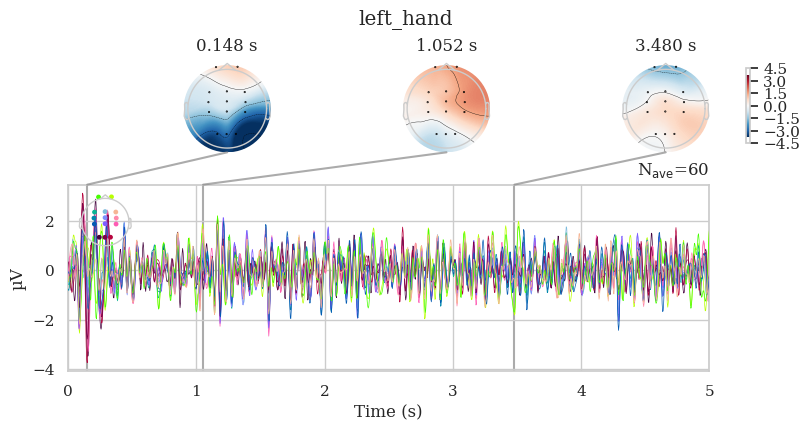

No projector specified for this dataset. Please consider the method self.add_proj.


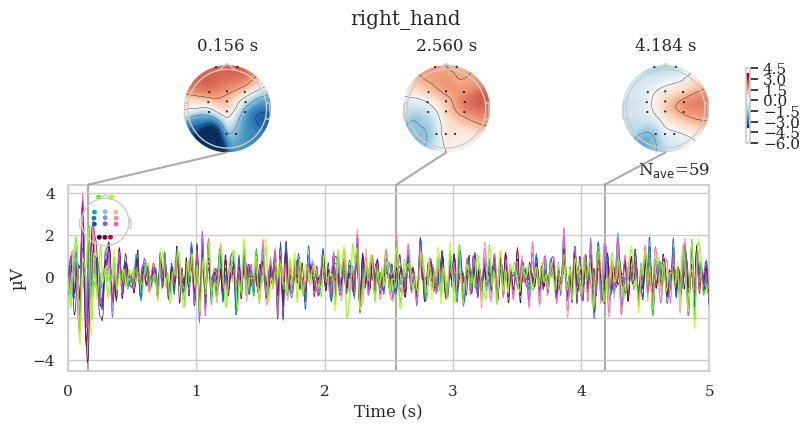

In [4]:
import numpy as np
ts_args=dict(ylim=dict(
    #eeg=[-15,15]
))
joint_args=dict(ts_args=ts_args)
for cls in np.unique(labels):
    evoked = epochs[cls].average()
    if len(evoked.ch_names) > 1:
        evoked.plot_joint(title=cls, **joint_args)
    else:
        evoked.plot(**ts_args)

In [5]:
from hoda.tensorize import stf_tensor
from sklearn.preprocessing import StandardScaler

X = epochs.get_data()
y = labels
X = stf_tensor(X, sfreq=epochs.info['sfreq'], zscore=True)
X = tl.tensor(X)
X.shape

/tmp/ipykernel_2254/2668743399.py:4: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = epochs.get_data()


(119, 14, 23, 125)

<Axes: >

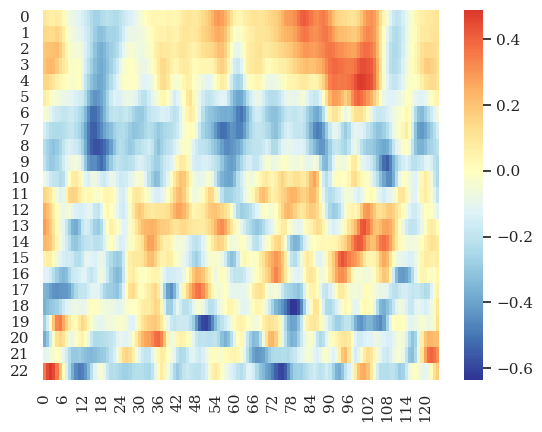

In [6]:
import seaborn as sns
contrast = tl.to_numpy(X[y=='right_hand'].mean(axis=0)) - tl.to_numpy(X[y=='left_hand'].mean(axis=0))
sns.heatmap(contrast[2], cmap="RdYlBu_r", center=0)

In [7]:
from hoda.hoda import HODA

hoda = HODA(
        rank=[1,1,1],
        max_iter=128,
        tol=1e-12,
        init ='eye',
        shrinkage='lw',
        toeplitz=None,
        obj='tr',
        solver='lanczos',
        taper=False,
        extra_train_info=True,
        verbose=True,
        random_state=42,
        delta=None,
        forward=True,
)


In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('default')

hoda.fit_backward(X,y)
df = pd.DataFrame(hoda.train_info_['backward'])
display(df)

  0%|          | 0/128 [00:00<?, ?it/s]

,iteration,mode,update,shrinkage,rank,objective,F_tr,F_rt
0,1,0,1.307189e+00,0.097140,1,9.879791e+05,0.000429,0.000843
1,1,1,1.206425e+00,0.071305,1,6.233095e+05,0.001187,0.002335
2,1,2,1.183915e+00,0.160310,1,1.892574e+05,0.002977,0.005854
3,2,0,8.300017e-01,0.053058,1,1.657528e+06,0.003482,0.006848
4,2,1,5.718954e-01,0.095961,1,4.393751e+05,0.004650,0.009144
...,...,...,...,...,...,...,...,...
379,127,1,1.256328e-07,0.099908,1,2.359923e+05,0.026339,0.051792
380,127,2,1.371149e-07,0.191461,1,9.711110e+04,0.026339,0.051792
381,128,0,1.040494e-07,0.080974,1,4.720779e+05,0.026339,0.051792
382,128,1,1.107459e-07,0.099908,1,2.359923e+05,0.026339,0.051792


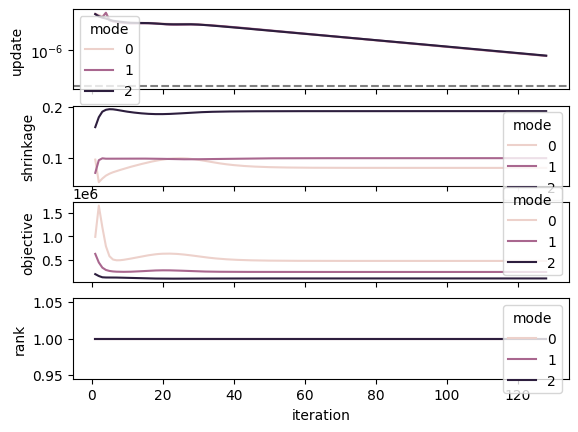

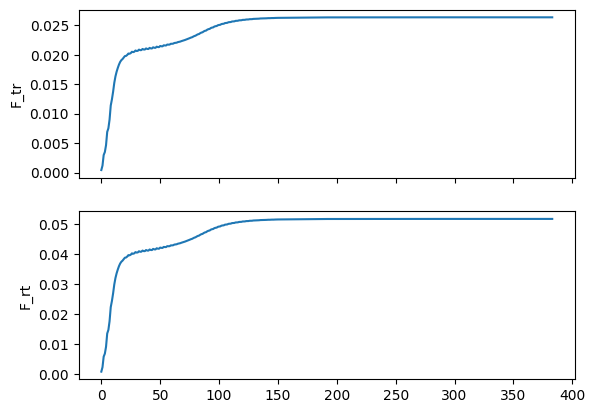

In [9]:
fig, axs = plt.subplots(4,1, sharex=True)
sns.lineplot(data=df, x='iteration', y='update',hue='mode', ax=axs[0])
axs[0].axhline(hoda.tol, color='grey', linestyle='--')
axs[0].set_yscale('log')
sns.lineplot(data=df, x='iteration', y='shrinkage',hue='mode', ax=axs[1])
sns.lineplot(data=df, x='iteration', y='objective',hue='mode', ax=axs[2])
sns.lineplot(data=df, x='iteration', y='rank',hue='mode', ax=axs[3])
if hoda.extra_train_info:
    fig, axs = plt.subplots(2,1, sharex=True)
    sns.lineplot(data=df, x=df.index, y='F_tr', ax=axs[0])
    sns.lineplot(data=df, x=df.index, y='F_rt', ax=axs[1])

In [22]:
tl.tenalg.set_backend('einsum')
tl.plugins.use_opt_einsum()

hoda.fit_forward(X,y)
df = pd.DataFrame(hoda.train_info_['forward'])
display(df)



  0%|          | 0/128 [00:00<?, ?it/s]

,iteration,mode,update,shrinkage,mse
0,0,0,inf,NaN,0.999767
1,0,1,inf,NaN,0.999767
2,0,2,inf,NaN,0.999767
3,1,0,1.975200e+00,0.0,0.999527
4,1,1,1.230876e+00,0.0,0.999069
...,...,...,...,...,...
106,35,1,1.004793e-12,0.0,0.997116
107,35,2,8.860997e-13,0.0,0.997116
108,36,0,4.879179e-13,0.0,0.997116
109,36,1,4.682828e-13,0.0,0.997116


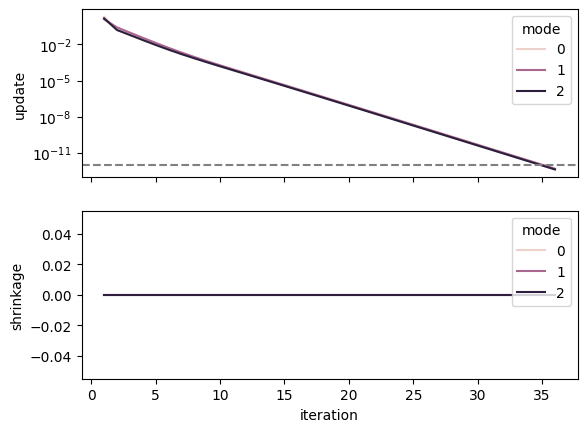

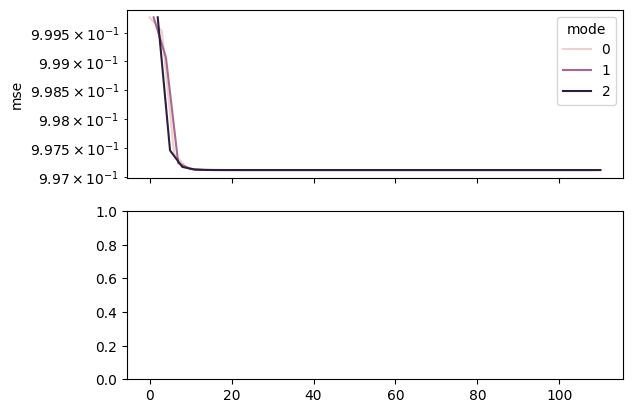

In [23]:

fig, axs = plt.subplots( 2,1, sharex=True)
sns.lineplot(data=df, x='iteration', y='update',hue='mode', ax=axs[0])
axs[0].axhline(hoda.tol, color='grey', linestyle='--')
axs[0].set_yscale('log')
sns.lineplot(data=df, x='iteration', y='shrinkage',hue='mode', ax=axs[1])
if hoda.extra_train_info:
    fig, axs = plt.subplots(2,1, sharex=True)
    sns.lineplot(data=df, x=df.index, y='mse', ax=axs[0], hue='mode')
    axs[0].set_yscale('log')
    #sns.lineplot(data=df, x=df.index, y='err_cross_corr', ax=axs[1])
    #axs[1].set_yscale('log')

In [123]:
#G_cov = tl.tensordot(G.T, G, axes=1)/(n_samples-1)
n_samples = len(X)
Xt = hoda.transform(X)

Xt_flat = tl.to_numpy(Xt.reshape(n_samples, -1))
if Xt_flat.shape[-1] > 1:
    sns.heatmap(np.corrcoef(Xt_flat, rowvar=False),  cmap='vlag', center=0)

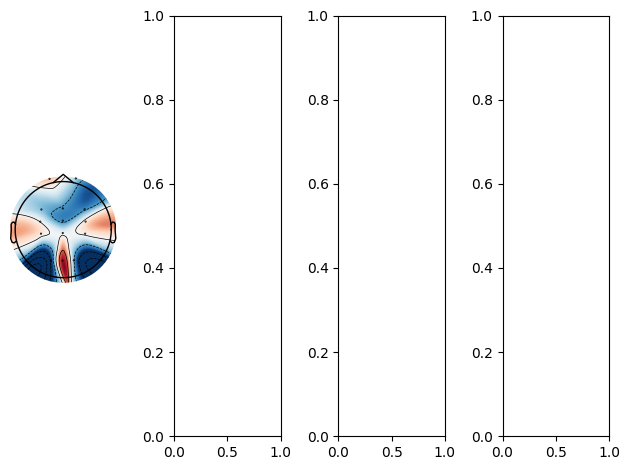

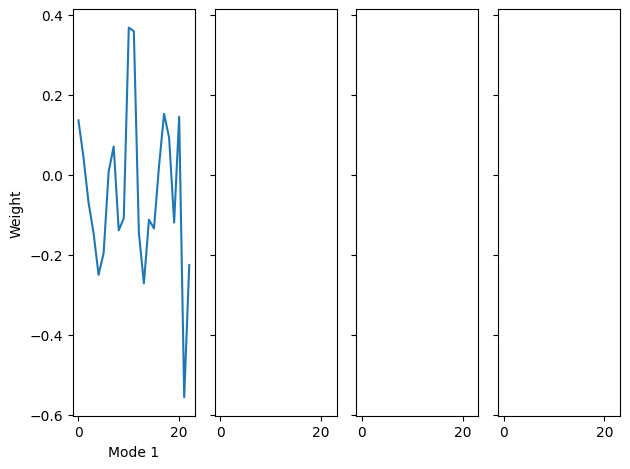

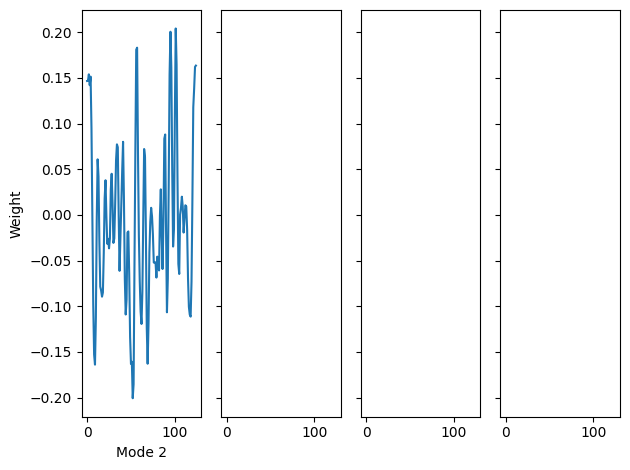

In [71]:
import numpy as np
from mne.viz import plot_topomap
import matplotlib.pyplot as plt
import tensorly as tl

col_wrap = 4


n_col = col_wrap
n_row = int( np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
vmax = float(tl.max(tl.abs(hoda.weights_[0])))
for i in range(hoda.rank_[0]):
    w = tl.to_numpy(hoda.weights_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs.flatten()[i], show=False, vlim=[-vmax, vmax])

order = X.ndim-1
for k in range(1, order):
    n_row = int( np.ceil(hoda.rank_[k] / col_wrap)) 
    fig, axs = plt.subplots(n_row, n_col,  layout='tight', sharex=True, sharey=True)
    for i in range(hoda.rank_[k]):
        w = tl.to_numpy(hoda.weights_[k][:,i])
        axs.flatten()[i].plot(w)
        axs.flatten()[i].set_xlabel(f'Mode {k}')
        axs.flatten()[i].sharey(axs.flatten()[0])
    axs.flatten()[0].set_ylabel('Weight');

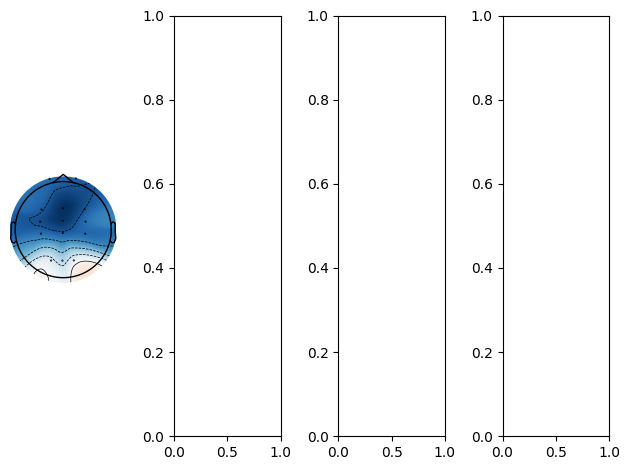

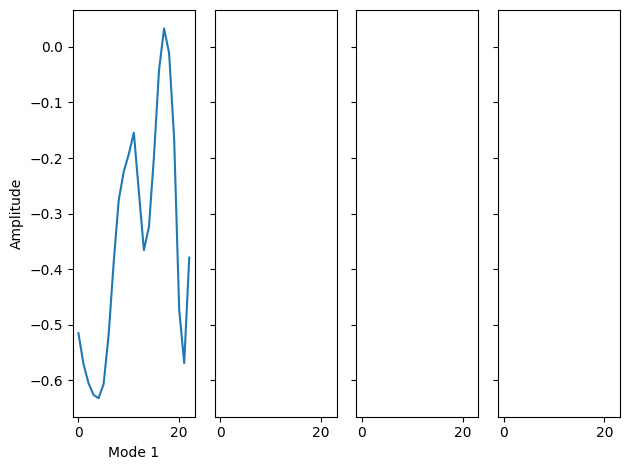

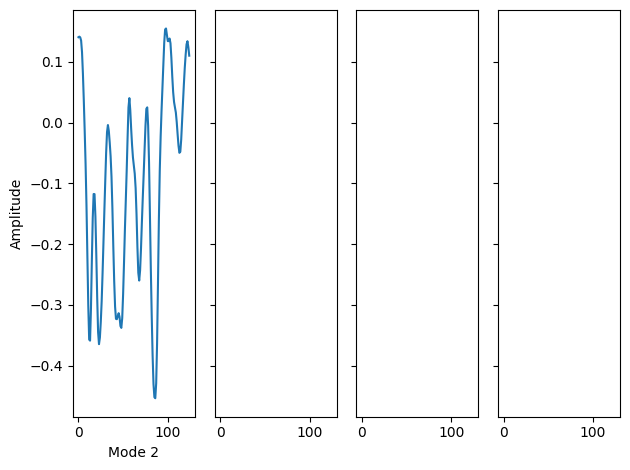

In [23]:

n_row = int(np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
A = hoda.aps_[0]
vmax = float(tl.max(tl.abs(A)))
for i in range(hoda.rank_[0]):
    a = tl.to_numpy(A[:,i])
    plot_topomap(a, epochs.info, axes=axs.flatten()[i], show=False, vlim=[-vmax, vmax])

for k in range(1, order):
    n_row = int(np.ceil(hoda.rank_[k] / col_wrap)) 
    fig, axs = plt.subplots(
        n_row, n_col, 
        layout='tight', 
        sharex=True,
        sharey=True
    )
    A = hoda.aps_[k]
    for i in range(hoda.rank_[k]):
        a = tl.to_numpy(A[:,i])
        axs.flatten()[i].plot(a)
        axs.flatten()[i].set_xlabel(f'Mode {k}')
        axs.flatten()[i].sharey(axs.flatten()[0])
    axs.flatten()[0].set_ylabel('Amplitude');

In [24]:
from sklearn.decomposition import PCA
import seaborn as sns
from matplotlib import pyplot as plt

if Xt.shape[-1] > 1:
    n_components = 2
    decomp  = PCA(n_components=n_components, whiten=False)
    Xt_viz = decomp.fit_transform(Xt_flat)
    df = pd.DataFrame(Xt_viz, columns=['PC1', 'PC2'])
    df['label'] = y
    df=df.reset_index()
    print(df)
    sns.scatterplot(data=df, x='PC1', y='PC2', hue='label',)
    sns.kdeplot(data=df, x='PC1', y='PC2', hue='label',)
    ax = plt.gca()    
    ax.spines['bottom'].set_position('zero')
    ax.spines['left'].set_position('zero')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
